In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


In [4]:

loading = False
if(loading):
    nbSeeds = 10
    envs = ["walker2d"]
    descriptors = ["nbInstr", "actionValues"]

    allDf = []

    for env in envs:
        for seed in range(nbSeeds):
            for descriptor in descriptors:
                dfLocal = pd.read_csv("feetContactArchive/feetContactArchive.{}.{}.{}.csv".format(seed, descriptor, env))
                dfLocal = dfLocal.rename(columns={
                    "feet 0": "feet0",
                    "feet 1": "feet1"
                })
                dfLocal["env"] = env
                dfLocal["descriptor"] = descriptor
                dfLocal["seed"] = seed

                allDf.append(dfLocal)

            dfLocal = pd.read_csv("feetContactArchive/feetContactArchive.{}.double.actionValues.{}.csv".format(seed, env))
            dfLocal = dfLocal.rename(columns={
                "feet 0": "feet0",
                "feet 1": "feet1"
            })
            dfLocal["env"] = env
            dfLocal["descriptor"] = "doubleArchive"
            dfLocal["seed"] = seed
            dfLocal["doubleSpecific"] = "actionValues"
            allDf.append(dfLocal)


            dfLocal = pd.read_csv("feetContactArchive/feetContactArchive.{}.double.nbInstr.{}.csv".format(seed, env))
            dfLocal = dfLocal.rename(columns={
                "feet 0": "feet0",
                "feet 1": "feet1"
            })
            dfLocal["env"] = env
            dfLocal["descriptor"] = "doubleArchive"
            dfLocal["seed"] = seed
            dfLocal["doubleSpecific"] = "nbInstr"

            allDf.append(dfLocal)

    df = pd.concat(allDf)

    df.to_csv("dataMapElitesMapping.csv")

    df.describe()

else:
    df = pd.read_csv("dataMapElitesMapping.csv")

In [5]:
df.tail()

,Unnamed: 0,score,feet0,feet1,env,descriptor,seed,doubleSpecific
39995,995,2423.12,0.242826,0.424664,walker2d,doubleArchive,9,nbInstr
39996,996,1901.87,0.442550,0.329050,walker2d,doubleArchive,9,nbInstr
39997,997,2729.56,0.241617,0.588438,walker2d,doubleArchive,9,nbInstr
39998,998,1955.22,0.413150,0.316700,walker2d,doubleArchive,9,nbInstr
39999,999,2416.30,0.265093,0.416895,walker2d,doubleArchive,9,nbInstr


In [6]:
nCells = 33
cell_size = 1.0 / nCells

In [7]:
df["cell_x"] = (df["feet0"] * nCells).astype(int)
df["cell_y"] = (df["feet1"] * nCells).astype(int)

# clamp edge cases (value == 1.0)
df["cell_x"] = df["cell_x"].clip(0, nCells-1)
df["cell_y"] = df["cell_y"].clip(0, nCells-1)

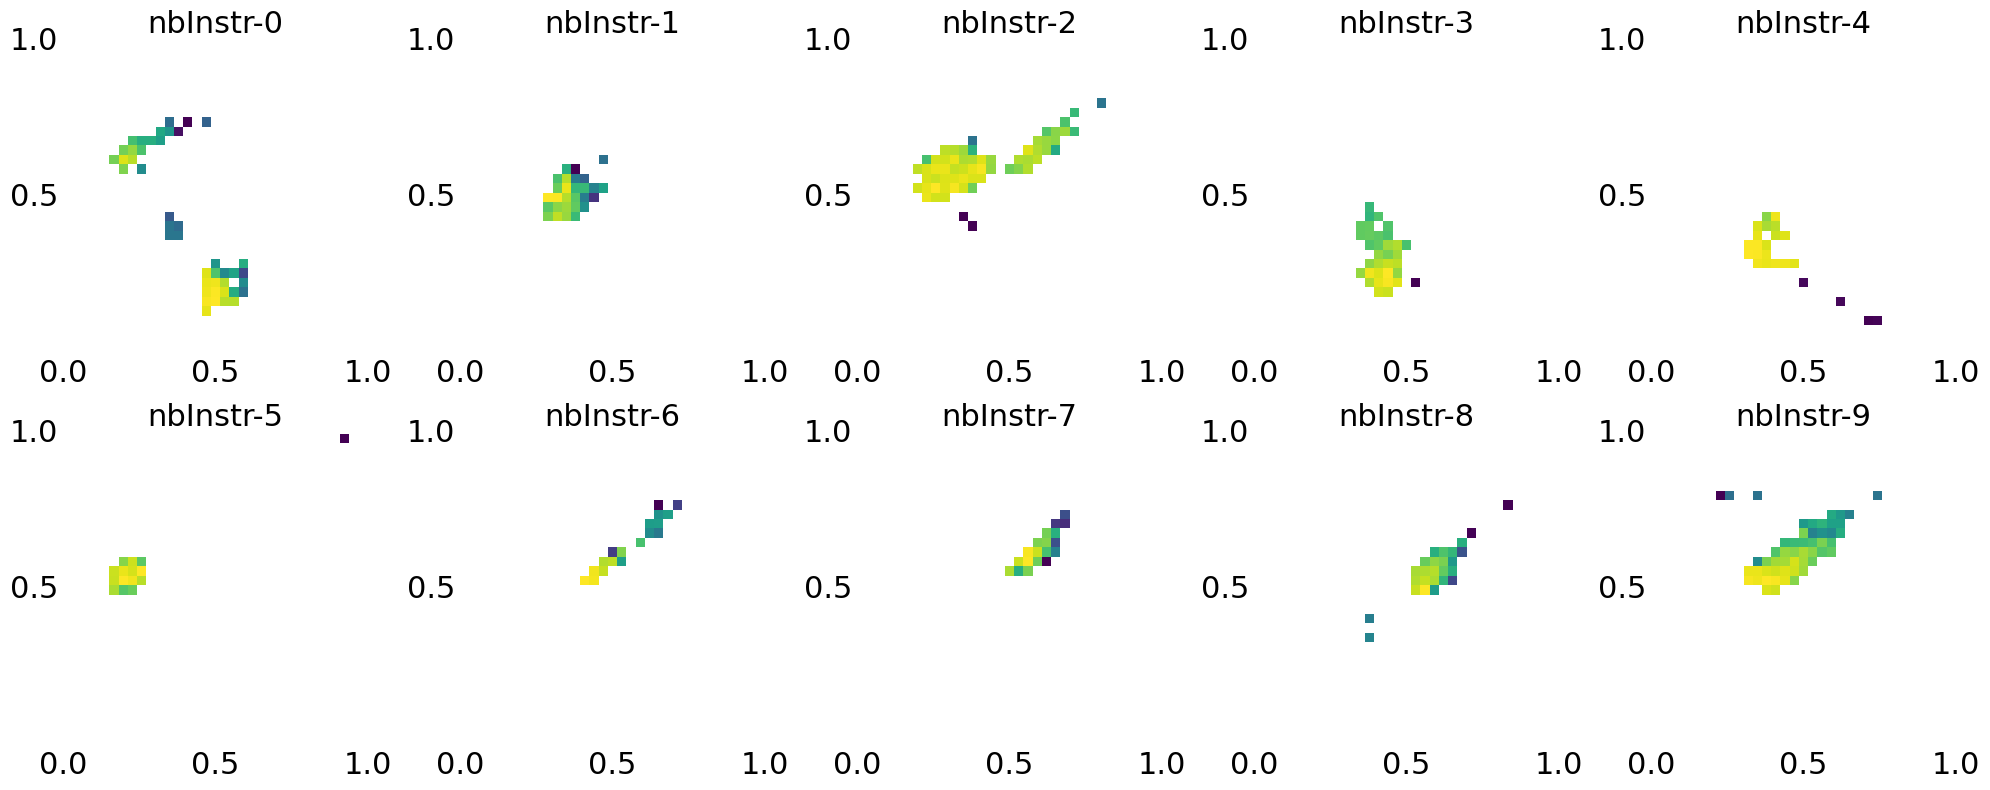

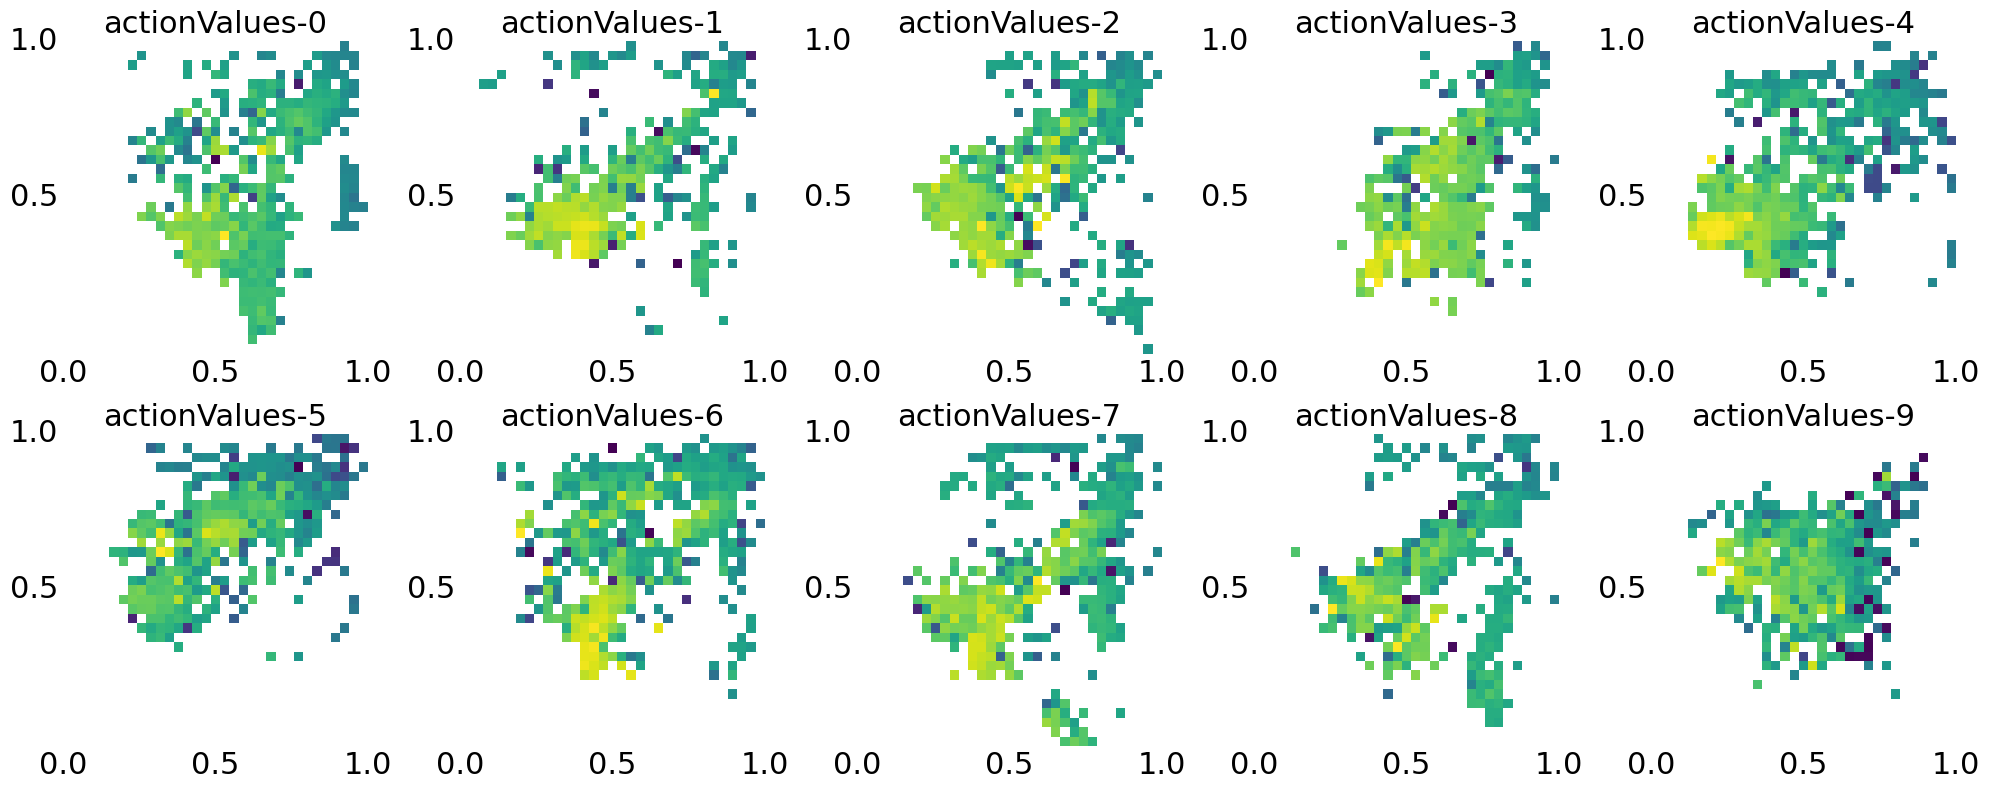

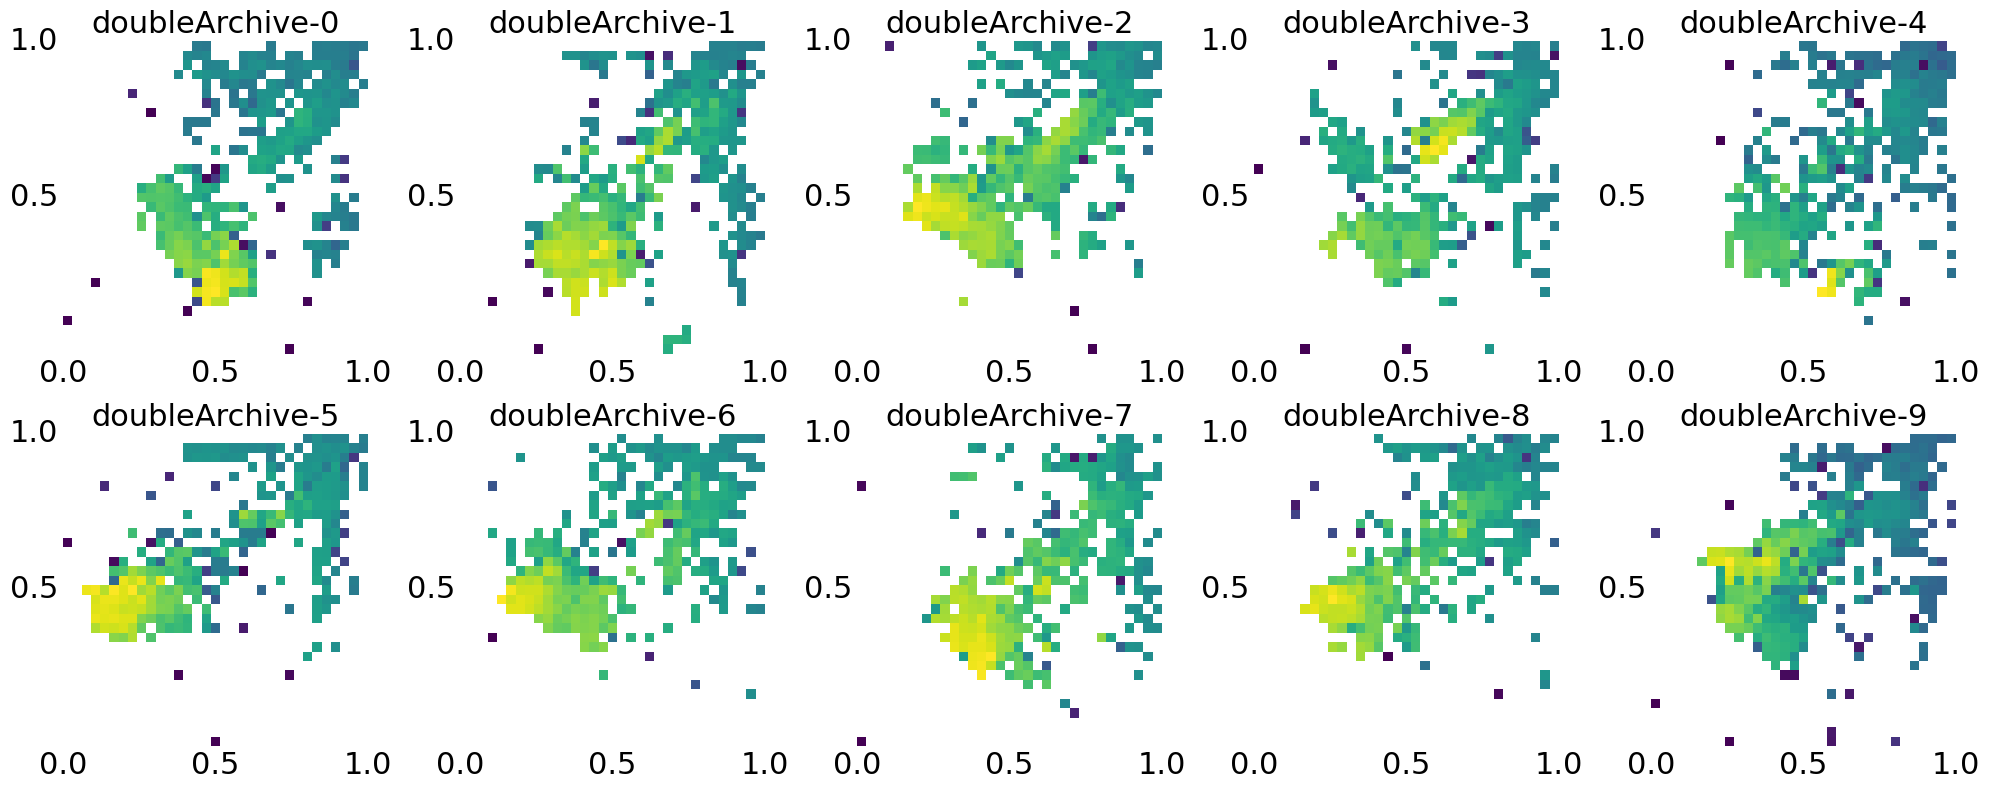

In [8]:

for descriptor in df["descriptor"].unique():

    descriptorDF = df[df["descriptor"] == descriptor]


    # Assuming `df` is your DataFrame and `nCells` is defined
    nbSeeds = len(df["seed"].unique())

    # Calculate the number of rows and columns for subplots
    nCols = math.ceil(5)
    nRows = math.ceil(2)

    # Create a figure with subplots
    fig, axes = plt.subplots(nRows, nCols, figsize=(nCols * 4, nRows * 4))
    axes = axes.flatten()  # Flatten the axes array for easy iteration



    for i, seed in enumerate(df["seed"].unique()):
        localDf = descriptorDF[descriptorDF["seed"] == seed]

        best_scores = (
            localDf.groupby(["cell_x", "cell_y"])["score"]
            .max()
            .reset_index()
        )

        heatmap = np.full((nCells, nCells), np.nan)

        for _, row in best_scores.iterrows():
            x = int(row["cell_x"])
            y = int(row["cell_y"])
            heatmap[y, x] = row["score"]

        ticks = np.linspace(0, nCells, 6)

        ax = sns.heatmap(heatmap, cmap="viridis", ax=axes[i], cbar=False)
        ax.invert_yaxis()

        ticksX = np.array([0, 0.5, 1.0]) * nCells
        ticksY = np.array([0.5, 1.0]) * nCells
        ax.set_xticks(ticksX)
        ax.set_yticks(ticksY)

        ax.set_xticklabels(np.round(ticksX / nCells, 2), rotation=0)
        ax.set_yticklabels(np.round(ticksY / nCells, 2))

        ax.set_title(f"{descriptor}-{seed}", fontsize=22)
        ax.tick_params(axis='both', labelsize=22, length=0)

    # Hide any unused subplots
    for j in range(i + 1, nRows * nCols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f'exported_results/archive_allSeeds_{descriptor}.pdf', format="pdf", dpi=100, transparent=True, bbox_inches='tight')
    plt.show()


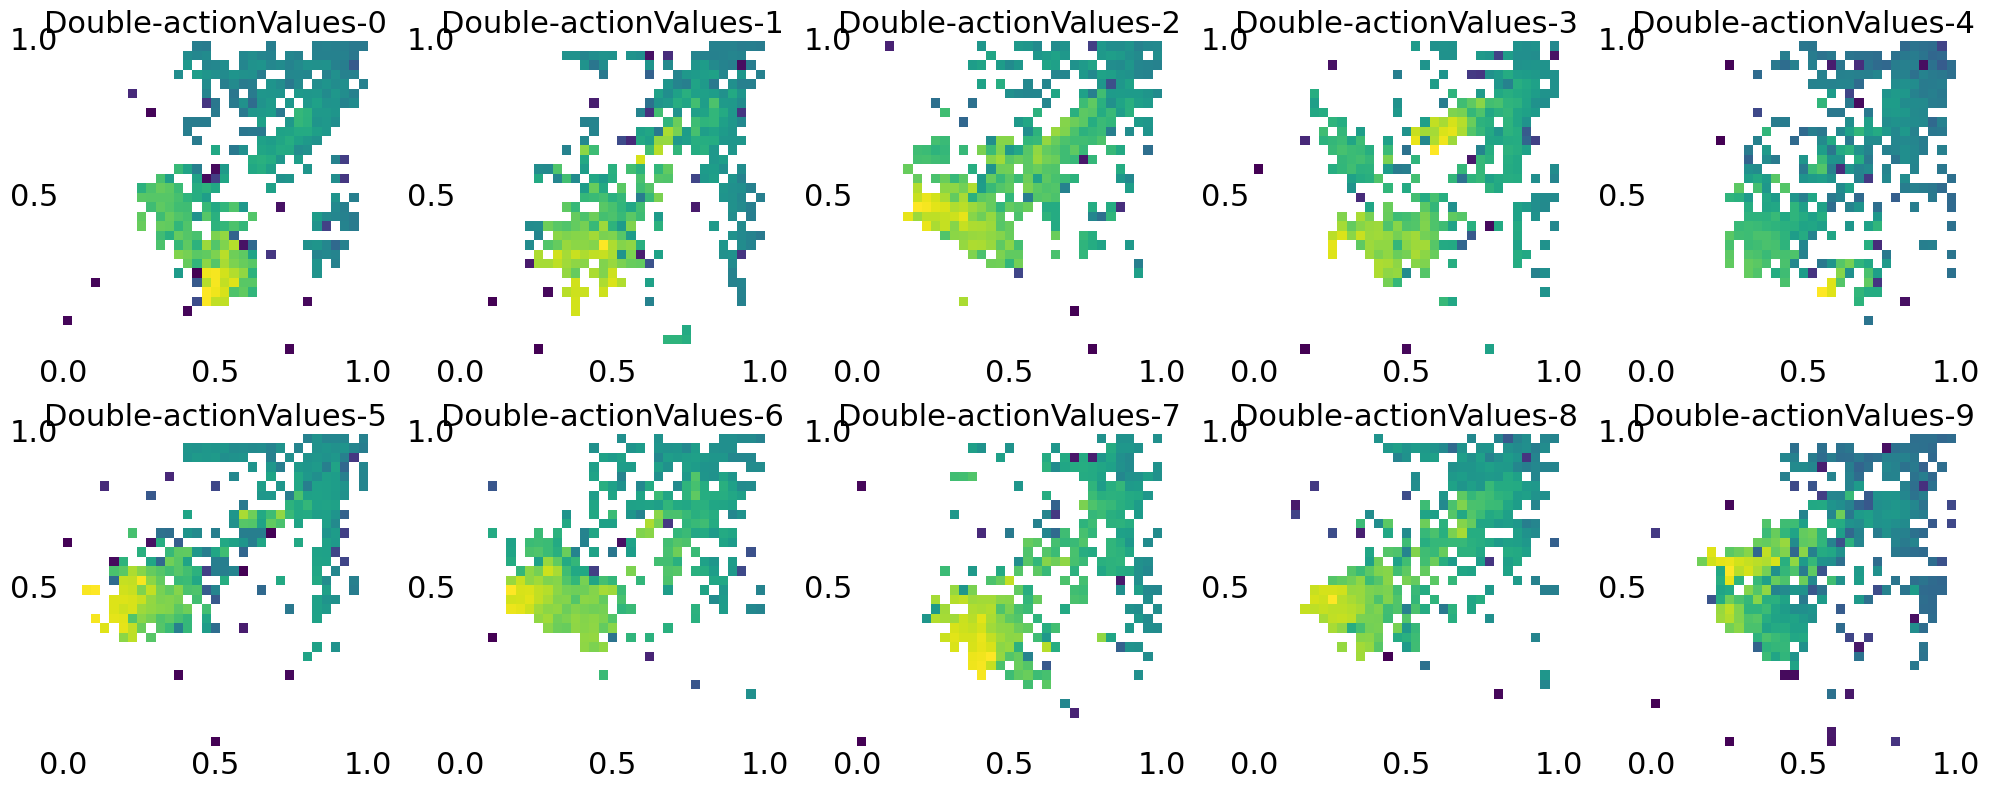

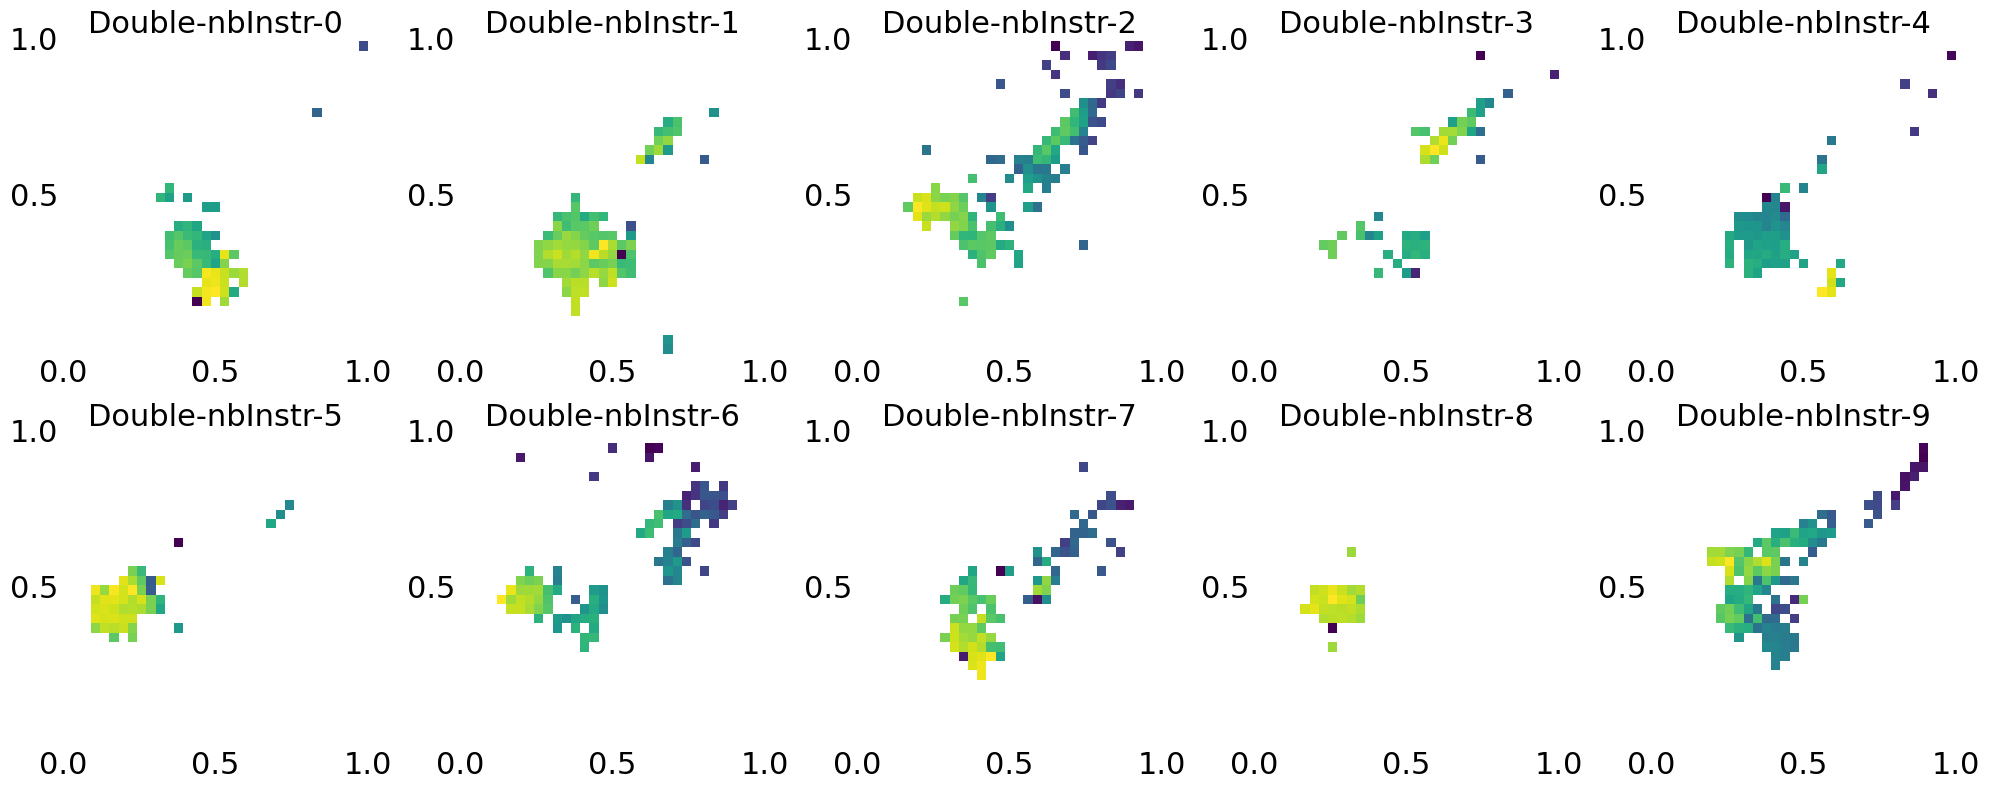

In [9]:
currentDf = df[df["descriptor"] == "doubleArchive"]
for doubleValue in currentDf["doubleSpecific"].unique():

    descriptorDF = currentDf[currentDf["doubleSpecific"] == doubleValue]


    # Assuming `df` is your DataFrame and `nCells` is defined
    nbSeeds = len(df["seed"].unique())

    # Calculate the number of rows and columns for subplots
    nCols = math.ceil(5)
    nRows = math.ceil(2)

    # Create a figure with subplots
    fig, axes = plt.subplots(nRows, nCols, figsize=(nCols * 4, nRows * 4))
    axes = axes.flatten()  # Flatten the axes array for easy iteration



    for i, seed in enumerate(df["seed"].unique()):
        localDf = descriptorDF[descriptorDF["seed"] == seed]

        best_scores = (
            localDf.groupby(["cell_x", "cell_y"])["score"]
            .max()
            .reset_index()
        )

        heatmap = np.full((nCells, nCells), np.nan)

        for _, row in best_scores.iterrows():
            x = int(row["cell_x"])
            y = int(row["cell_y"])
            heatmap[y, x] = row["score"]

        ticks = np.linspace(0, nCells, 6)

        ax = sns.heatmap(heatmap, cmap="viridis", ax=axes[i], cbar=False)
        ax.invert_yaxis()

        ticksX = np.array([0, 0.5, 1.0]) * nCells
        ticksY = np.array([0.5, 1.0]) * nCells
        ax.set_xticks(ticksX)
        ax.set_yticks(ticksY)

        ax.set_xticklabels(np.round(ticksX / nCells, 2), rotation=0)
        ax.set_yticklabels(np.round(ticksY / nCells, 2))

        ax.set_title(f"Double-{doubleValue}-{seed}", fontsize=22)
        ax.tick_params(axis='both', labelsize=22, length=0)

    # Hide any unused subplots
    for j in range(i + 1, nRows * nCols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f'exported_results/archive_allSeeds_doubleArchive_{doubleValue}.pdf', format="pdf", dpi=100, transparent=True, bbox_inches='tight')
    plt.show()


15
304
274


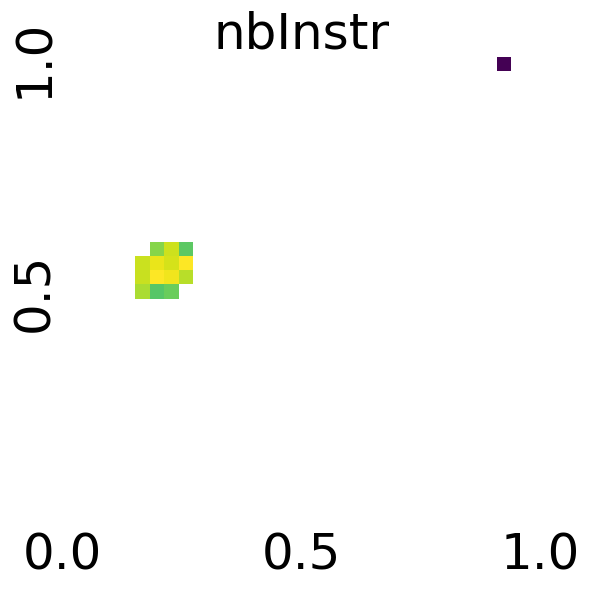

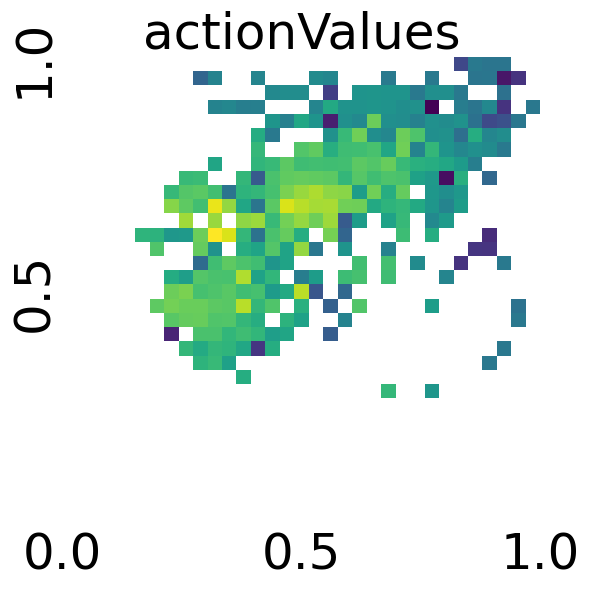

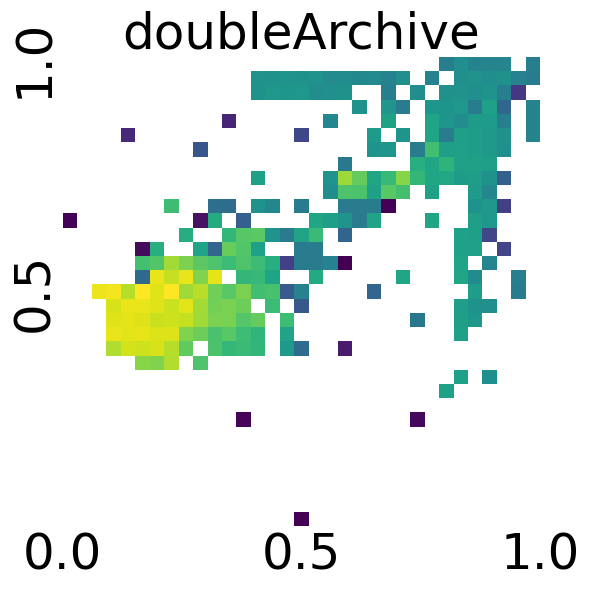

In [10]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

for descriptor in df["descriptor"].unique():
    descriptorDF = df[df["descriptor"] == descriptor]

    for seed in df["seed"].unique():
        if(seed) != 5:
            continue
        localDf = descriptorDF[descriptorDF["seed"] == seed]

        best_scores = (
            localDf.groupby(["cell_x", "cell_y"])["score"]
            .max()
            .reset_index()
        )

        heatmap = np.full((nCells, nCells), np.nan)

        for _, row in best_scores.iterrows():
            x = int(row["cell_x"])
            y = int(row["cell_y"])
            heatmap[y, x] = row["score"]

        # Boolean mask: non-zero and not NaN
        mask = (heatmap != 0) & (~np.isnan(heatmap))

        print(np.count_nonzero(mask))

        fig, ax = plt.subplots(figsize=(6, 6))  # One figure per seed
        sns.heatmap(heatmap, cmap="viridis", ax=ax, cbar=False)
        ax.invert_yaxis()

        ticksX = np.array([0, 0.5, 1.0]) * nCells
        ticksY = np.array([0.5, 1.0]) * nCells
        ax.set_xticks(ticksX)
        ax.set_yticks(ticksY)

        ax.set_xticklabels(np.round(ticksX / nCells, 2))
        ax.set_yticklabels(np.round(ticksY / nCells, 2))

        ax.set_title(f"{descriptor}", fontsize=36)
        ax.tick_params(axis='both', labelsize=36, length=0)

        plt.tight_layout()
        plt.savefig(f'exported_results/archive_seed{seed}_{descriptor}.png', format="png", dpi=100, transparent=True, bbox_inches='tight')
        break
        plt.show()


309
310
308
295
313
264
281
261
283
317
55
92
117
49
61
47
97
78
27
110


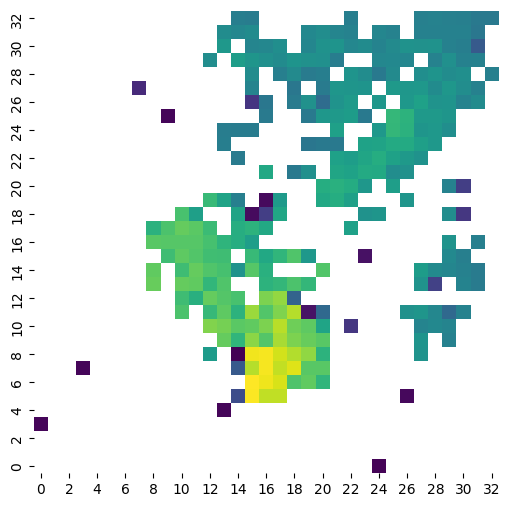

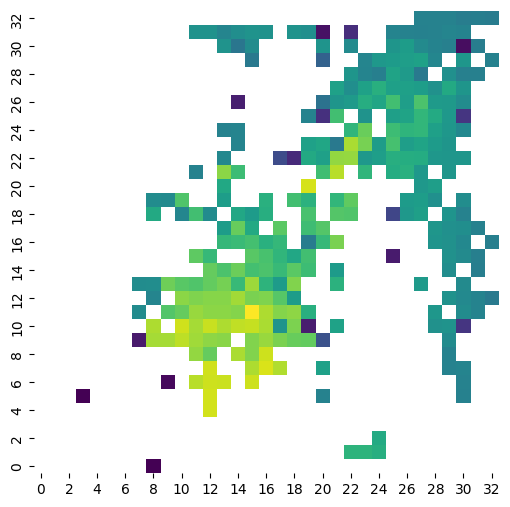

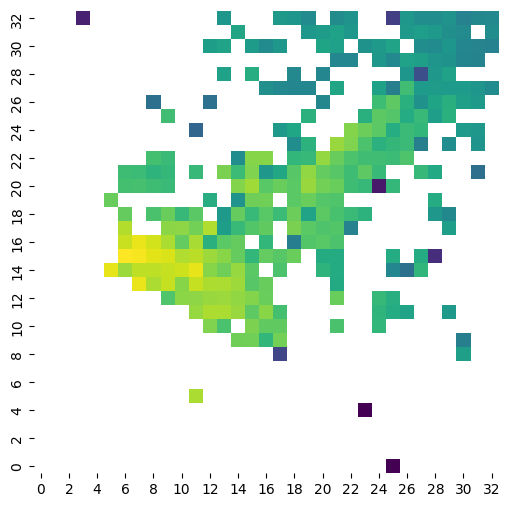

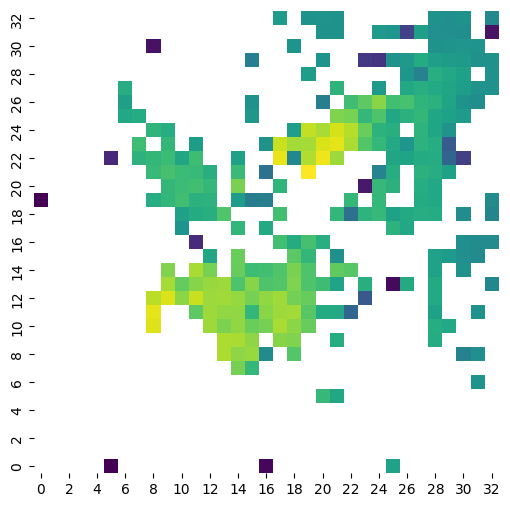

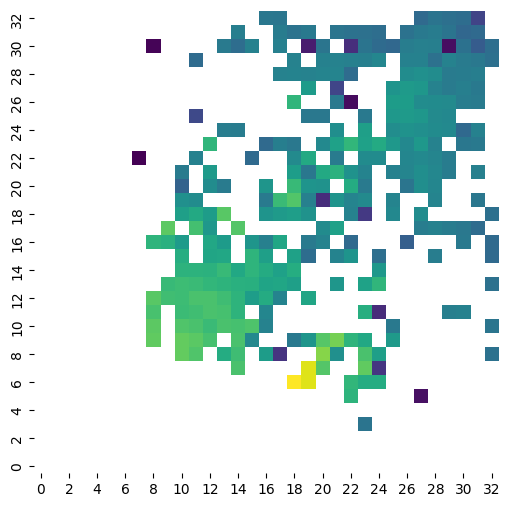

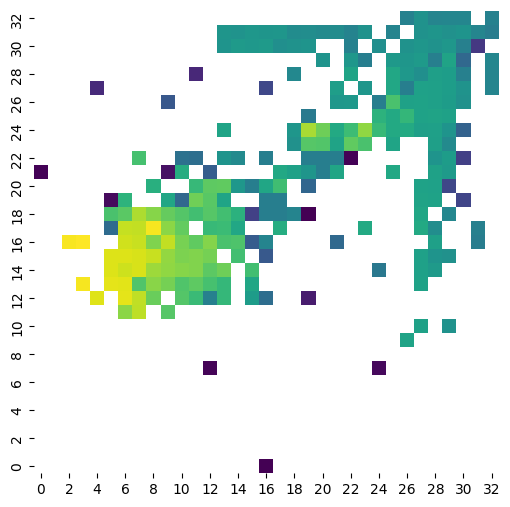

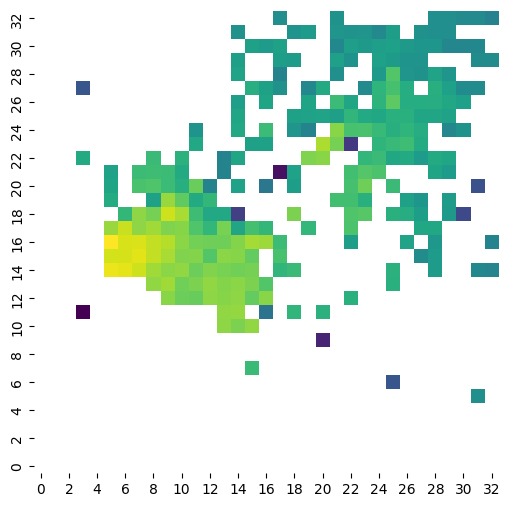

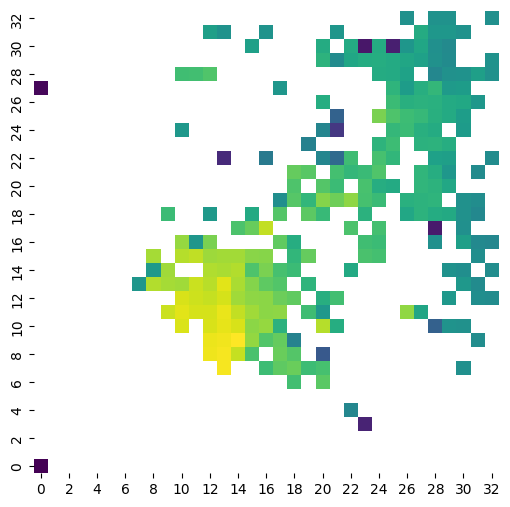

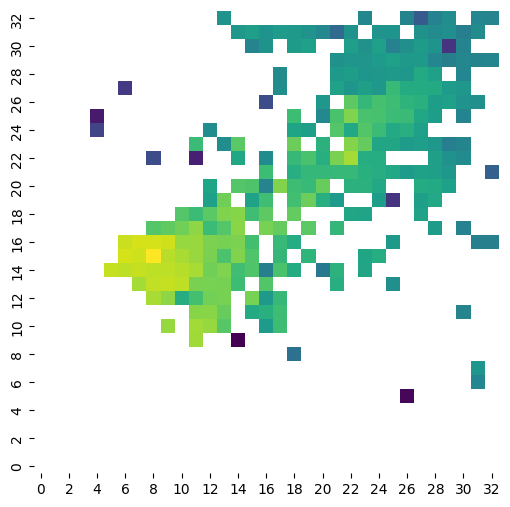

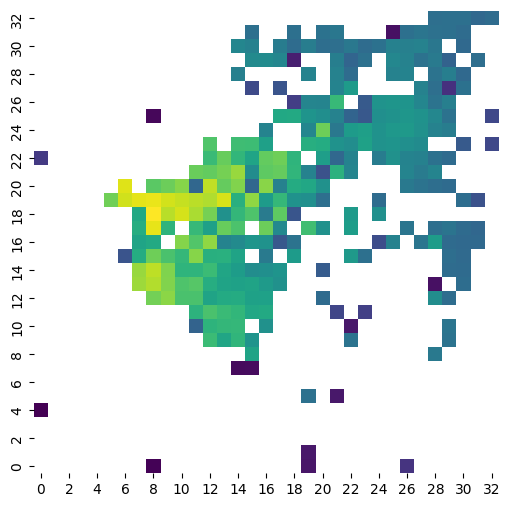

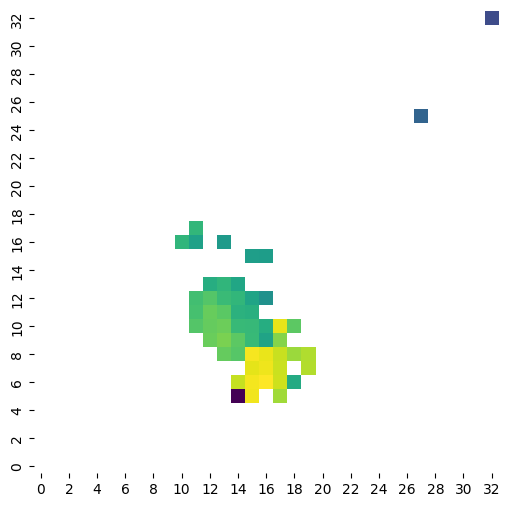

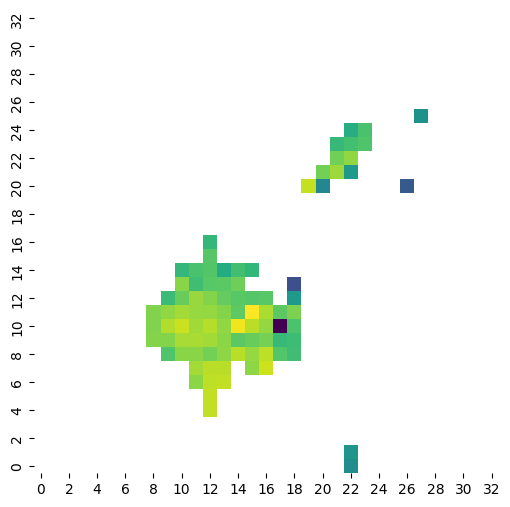

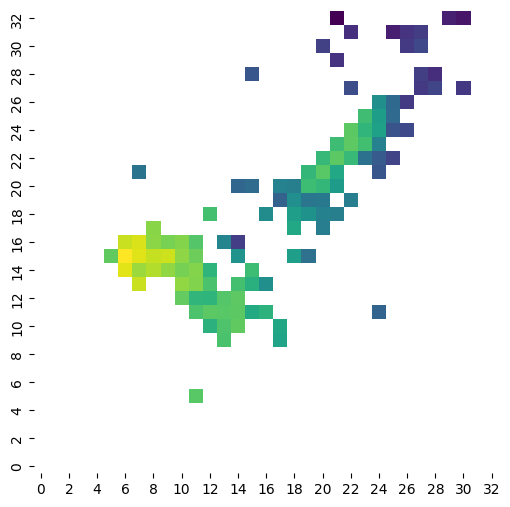

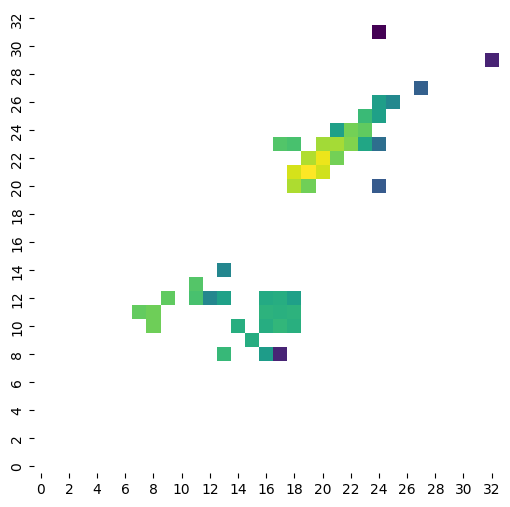

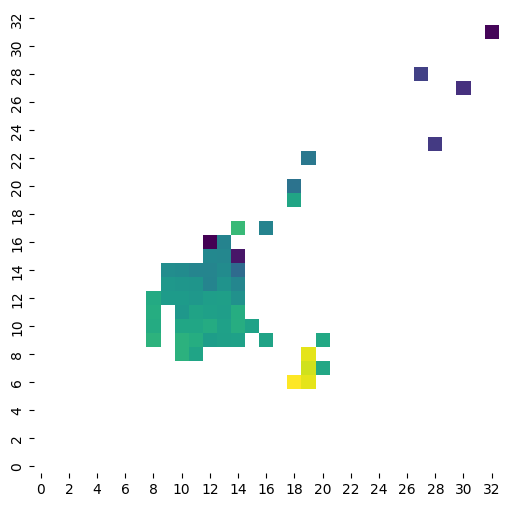

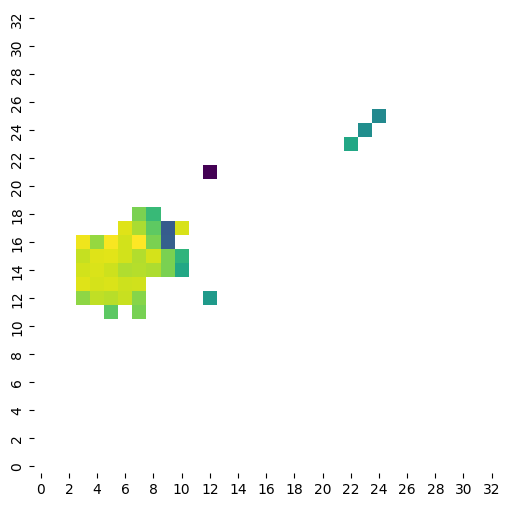

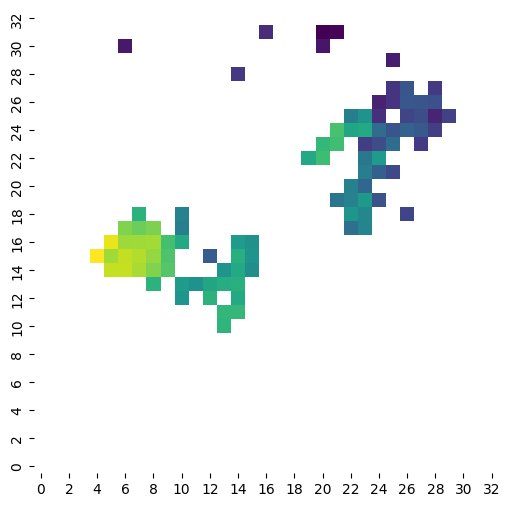

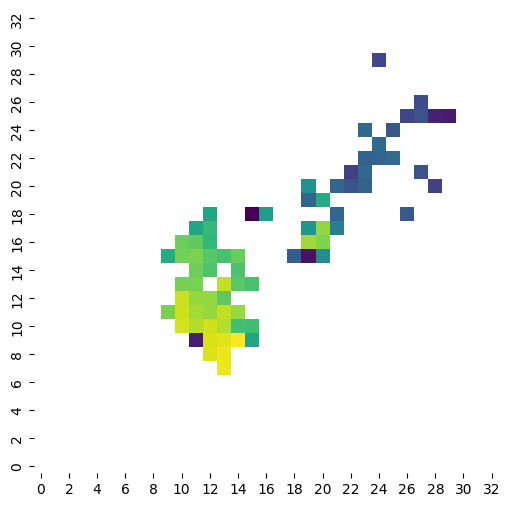

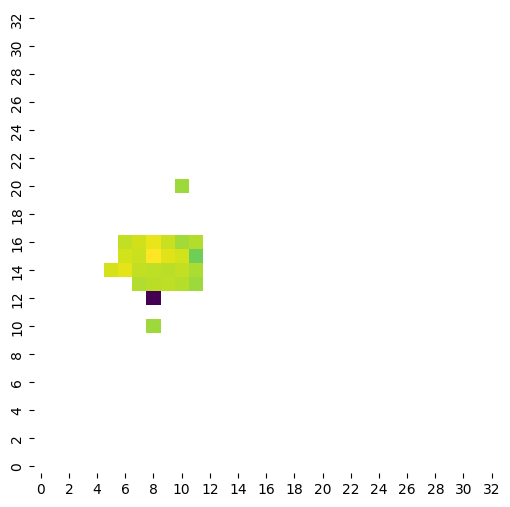

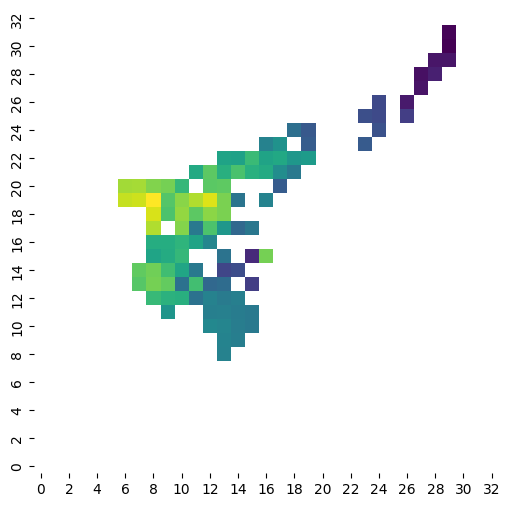

In [11]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


currentDf = df[df["descriptor"] == "doubleArchive"]

for doubleValue in currentDf["doubleSpecific"].unique():
    descriptorDF = currentDf[currentDf["doubleSpecific"] == doubleValue]

    for seed in descriptorDF["seed"].unique():  # Use descriptorDF here, not df

        localDf = descriptorDF[descriptorDF["seed"] == seed]

        best_scores = (
            localDf.groupby(["cell_x", "cell_y"])["score"]
            .max()
            .reset_index()
        )

        heatmap = np.full((nCells, nCells), np.nan)

        for _, row in best_scores.iterrows():
            x = int(row["cell_x"])
            y = int(row["cell_y"])
            heatmap[y, x] = row["score"]

        ticks = np.linspace(0, nCells, 6)

        fig, ax = plt.subplots(figsize=(6, 6))  # One figure per seed
        sns.heatmap(heatmap, cmap="viridis", ax=ax, cbar=False)
        ax.invert_yaxis()

        
        # Boolean mask: non-zero and not NaN
        mask = (heatmap != 0) & (~np.isnan(heatmap))

        print(np.count_nonzero(mask))
        continue

        ticksX = np.array([0, 0.5, 1.0]) * nCells
        ticksY = np.array([0.5, 1.0]) * nCells
        ax.set_xticks(ticksX)
        ax.set_yticks(ticksY)

        ax.set_xticklabels(np.round(ticksX / nCells, 2))
        ax.set_yticklabels(np.round(ticksY / nCells, 2))

        ax.set_title(f"Double-{doubleValue}", fontsize=36)
        ax.tick_params(axis='both', labelsize=36, length=0)

        plt.tight_layout()
        plt.savefig(f'exported_results/archive_seed{seed}_doubleArchive_{doubleValue}.pdf', format="pdf", dpi=100, transparent=True, bbox_inches='tight')
        plt.show()
